# 🧪 Statistical Tests — Worksheet
**Name:** _______________________   **Date:** _______________________

---
**How this works:**
- Each task gives you a question and a starting line or two
- You write the logic, the test, and the visualisation
- 💡 hints tell you *what* to use — not *how*
- Every chart needs a proper title, xlabel, ylabel — your job

```
p ≤ 0.05 → Reject H₀    |    p > 0.05 → Keep H₀
```
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
np.random.seed(42)
print('Ready')

Ready


---
## 📦 Dataset — Build It

Create a DataFrame called `df` with **200 student records** using these specs:

| Column | Details |
|--------|---------|
| `gender` | Male / Female, random |
| `study_hours` | Normal(mean=4, std=1.2), clipped 0–10 |
| `sleep_hours` | Normal(mean=7, std=1.0), clipped 4–10 |
| `marks` | `study*6 + sleep*2 + noise(0,8)`, clipped 0–100 |
| `subject` | Maths 40%, Science 35%, Arts 25% |
| `passed` | 'Yes' if marks ≥ 50 else 'No' |
| `school` | School A / B / C / D — equal chance |

After creating marks, add a school boost: A:+5, B:0, C:−5, D:+10 (clip to 100).

💡 `np.random.choice` · `np.random.normal` · `.clip()` · `np.where` · `pd.DataFrame`

In [ ]:

# For reproducibility
np.random.seed(42)

n = 200

# 1. Gender
gender = np.random.choice(['Male', 'Female'], size=n)

# 2. Study hours (Normal, clipped 0–10)
study_hours = np.random.normal(loc=4, scale=1.2, size=n)
study_hours = np.clip(study_hours, 0, 10)

# 3. Sleep hours (Normal, clipped 4–10)
sleep_hours = np.random.normal(loc=7, scale=1.0, size=n)
sleep_hours = np.clip(sleep_hours, 4, 10)

# 4. Noise
noise = np.random.normal(loc=0, scale=8, size=n)

# 5. Marks (before school boost)
marks = study_hours * 6 + sleep_hours * 2 + noise
marks = np.clip(marks, 0, 100)

# 6. Subject (with probabilities)
subject = np.random.choice(
    ['Maths', 'Science', 'Arts'],
    size=n,
    p=[0.40, 0.35, 0.25]
)

# 7. School (equal chance)
school = np.random.choice(['A', 'B', 'C', 'D'], size=n)

# 8. Apply school boost
boost_map = {'A': 5, 'B': 0, 'C': -5, 'D': 10}
marks = marks + pd.Series(school).map(boost_map)

# Clip again after boost
marks = np.clip(marks, 0, 100)

# 9. Passed column
passed = np.where(marks >= 50, 'Yes', 'No')

# 10. Create DataFrame
df = pd.DataFrame({
    'gender': gender,
    'study_hours': study_hours,
    'sleep_hours': sleep_hours,
    'marks': marks,
    'subject': subject,
    'passed': passed,
    'school': school
})
df.head().style.set_properties({
    'background-color': '#f9f9f9',
    'color': 'black',
    'border-color': 'black'
})
# Preview

print("\nShape:", df.shape)
df.head(10).style


Shape: (200, 7)


,gender,study_hours,sleep_hours,marks,subject,passed,school
0,Male,4.104456,7.199060,48.637314,Science,No,A
1,Female,3.641191,6.399783,47.136715,Science,No,D
2,Male,4.110113,7.069802,68.431328,Maths,Yes,A
3,Male,1.614917,6.614686,36.875476,Maths,No,A
4,Male,3.736394,7.113517,35.622056,Science,No,B
5,Female,4.428535,7.662131,29.251148,Science,No,C
6,Male,5.773473,8.586017,43.961300,Maths,No,A
7,Male,3.378076,5.762185,28.420533,Maths,No,C
8,Male,3.029808,9.133033,35.394107,Maths,No,A
9,Female,3.397892,5.047912,24.105144,Science,No,A


---
## Task 1 — Explore the Data (Visualisation)

Before any test, look at your data. Create a **2×2 grid of subplots**:
- `[0,0]` Histogram of `marks`
- `[0,1]` Histogram of `study_hours`
- `[1,0]` Boxplot of `marks` by `gender`
- `[1,1]` Boxplot of `marks` by `school`

Label everything. Write one observation below each plot as a comment.

💡 `plt.subplots(2,2)` · `ax.hist()` · `df.boxplot(column, by, ax=)`

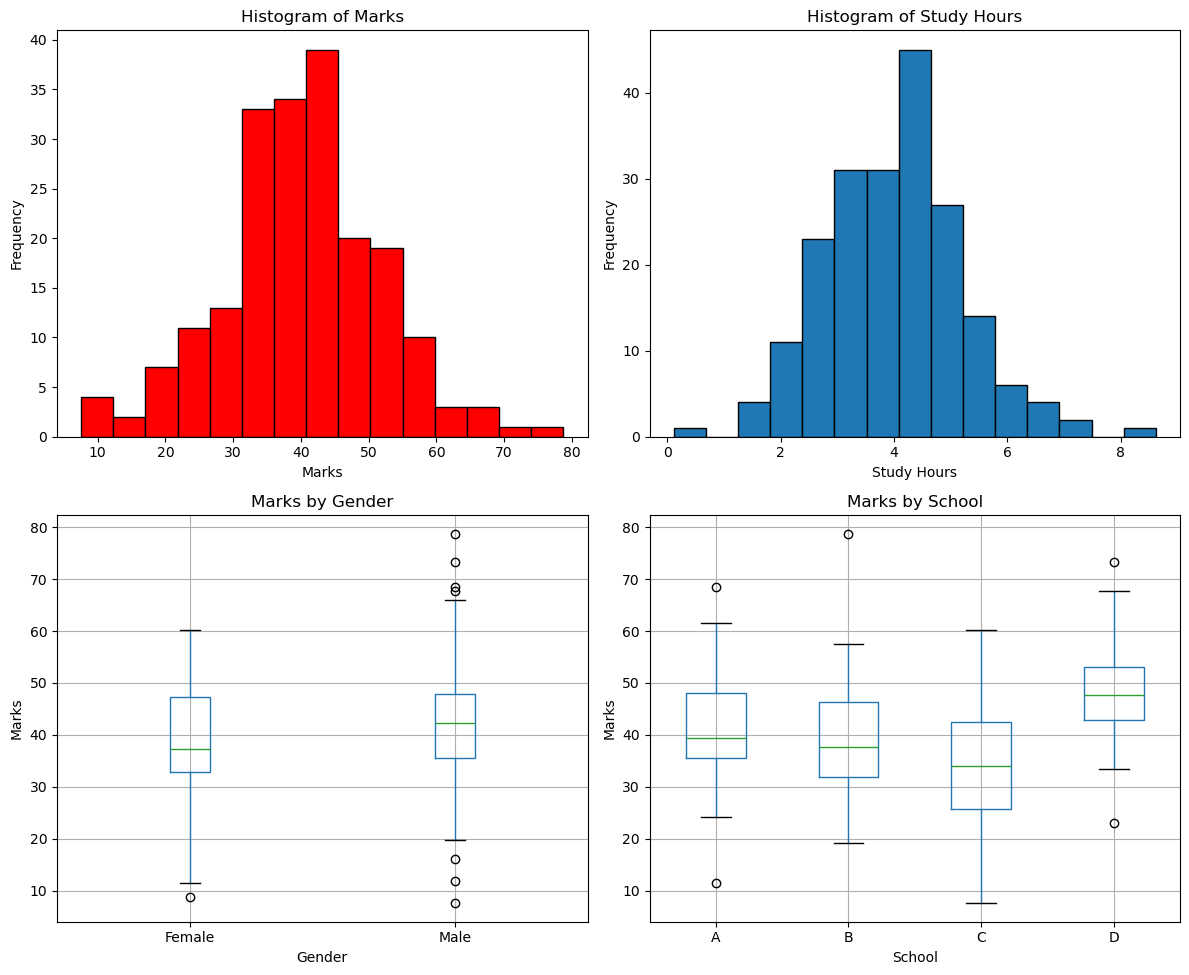

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# [0,0] Histogram of marks
ax[0,0].hist(df['marks'], bins=15, edgecolor='black',color='red')
ax[0,0].set_title("Histogram of Marks")
ax[0,0].set_xlabel("Marks")
ax[0,0].set_ylabel("Frequency")

# Observation:
# Most students have marks in the mid-range (around 40–70)

# [0,1] Histogram of study_hours
ax[0,1].hist(df['study_hours'], bins=15,edgecolor='black')
ax[0,1].set_title("Histogram of Study Hours")
ax[0,1].set_xlabel("Study Hours")
ax[0,1].set_ylabel("Frequency")

# Observation:
# Study hours are roughly normally distributed around 4 hours

# [1,0] Boxplot of marks by gender
df.boxplot(column='marks', by='gender', ax=ax[1,0])
ax[1,0].set_title("Marks by Gender")
ax[1,0].set_xlabel("Gender")
ax[1,0].set_ylabel("Marks")

# Observation:
# Male and Female students show similar median marks with slight variation

# [1,1] Boxplot of marks by school
df.boxplot(column='marks', by='school', ax=ax[1,1])
ax[1,1].set_title("Marks by School")
ax[1,1].set_xlabel("School")
ax[1,1].set_ylabel("Marks")

# Observation:
# School D appears to have higher marks due to positive boost

# Remove automatic extra title
plt.suptitle("")

plt.tight_layout()
plt.show()

---
## Task 2 — Normality Test

Test all three numeric columns (`marks`, `study_hours`, `sleep_hours`) for normality.

- Loop over the columns
- Run Shapiro-Wilk for each
- Print: column name, p-value, and verdict
- Draw Q-Q plots for all three in a 1×3 row

💡 `stats.shapiro()` · `stats.probplot(col, plot=ax)`

marks: Shapiro-Wilk stat=0.9920, p=0.3419
study_hours: Shapiro-Wilk stat=0.9883, p=0.1014
sleep_hours: Shapiro-Wilk stat=0.9940, p=0.5952


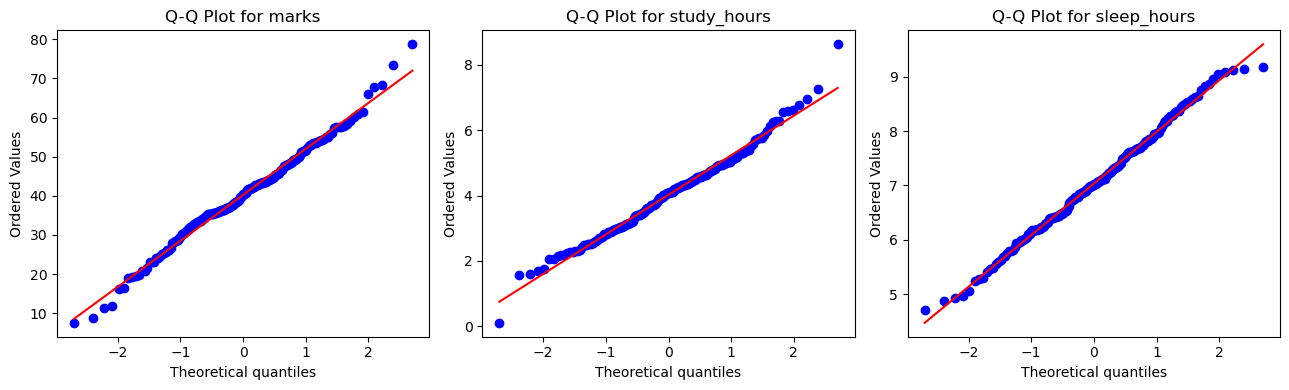

In [ ]:
cols = ['marks', 'study_hours', 'sleep_hours']
for col in cols:
    stat, p = stats.shapiro(df[col])
    print(f"{col}: Shapiro-Wilk stat={stat:.4f}, p={p:.4f}")    


# Loop + test + print





# Q-Q plots — 1×3
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for i, col in enumerate(cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot for {col}")
plt.tight_layout()
plt.show()

# Which columns are safe for parametric tests
# Answer: 
# All three columns (marks, study_hours, sleep_hours) have p-values > 0.05 in the Shapiro-Wilk test, indicating they do not significantly deviate from normality. Therefore, all three columns are safe for parametric tests.

---
## Task 3 — t-test: Gender vs Marks

**Question:** Do Male and Female students score differently?

- H₀: Male and female marks have the same mean
- H₁: Means are different

Run the test, print results, write your if/else verdict, then draw a **violin plot** split by gender.

💡 `stats.ttest_ind()` · `sns.violinplot()`

T-statistic = 1.8889, p-value = 0.0604
Fail to reject H0: Mean are different


C:\Users\hp\AppData\Local\Temp\ipykernel_30508\2601751126.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='school', y='marks', data=df, palette='pastel')


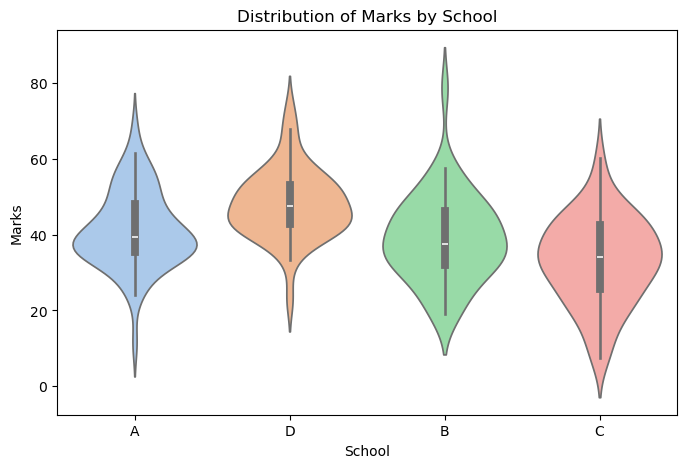

In [22]:
# Separate groups, run test, print, verdict, plot
import matplotlib.pyplot as plt

# Split marks by gender
male_marks = df[df['gender']=='Male']['marks']
female_marks = df[df['gender']=='Female']['marks']

# Independent t-test
t_stat, p_val = stats.ttest_ind(male_marks, female_marks)

print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")

# Verdict
if p_val < 0.05:
    print("Reject H0: Male and Female marks have the same mean")
else:
    print("Fail to reject H0: Mean are different")

plt.figure(figsize=(8,5))
sns.violinplot(x='school', y='marks', data=df, palette='pastel')
plt.title("Distribution of Marks by School")
plt.xlabel("School")
plt.ylabel("Marks")
plt.show()





---
## Task 4 — ANOVA + Post-hoc: Schools vs Marks

**Question:** Do all 4 schools score the same?

- Run ANOVA first — if significant, run Tukey HSD to find which pairs differ
- Print ANOVA result + Tukey summary
- Draw a **bar chart with error bars** (mean ± std per school)

💡 `stats.f_oneway(*groups)` · `pairwise_tukeyhsd(endog, groups, alpha=0.05)` · `ax.bar(yerr=)`

                      sum_sq     df          F        PR(>F)
C(school_full)   5338.679102    3.0  15.945894  2.570385e-09
Residual        21873.574617  196.0        NaN           NaN
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
School A School B  -2.2435 0.6995  -7.6042  3.1172  False
School A School C  -8.1323 0.0005 -13.3647 -2.8999   True
School A School D   6.8545 0.0064   1.4586 12.2505   True
School B School C  -5.8888 0.0375 -11.5407 -0.2369   True
School B School D    9.098 0.0004   3.2945 14.9016   True
School C School D  14.9868    0.0   9.3015 20.6721   True
---------------------------------------------------------


C:\Users\hp\AppData\Local\Temp\ipykernel_30508\3384236137.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='school_full', y='marks', data=df,
C:\Users\hp\AppData\Local\Temp\ipykernel_30508\3384236137.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='school_full', y='marks', data=df,


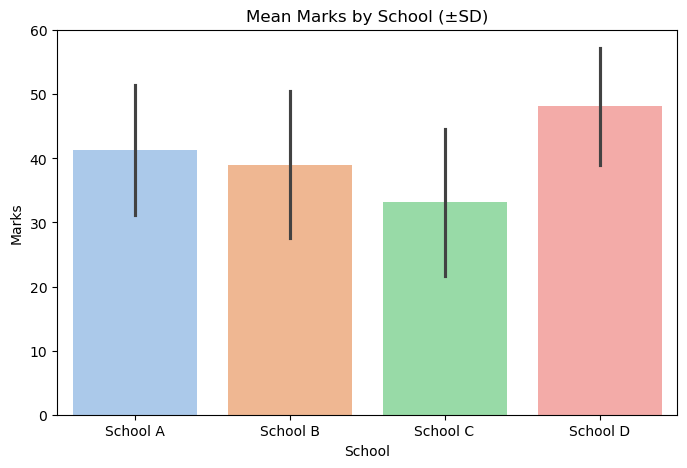

In [ ]:
school_order = ['School A', 'School B', 'School C', 'School D']

# Build groups, run ANOVA, run Tukey, bar chart with error bars
# Map school letters to full names for clarity
df['school_full'] = df['school'].map({
    'A': 'School A',
    'B': 'School B',
    'C': 'School C',
    'D': 'School D'
})
import statsmodels.api as sm
from statsmodels.formula.api import ols

# One-way ANOVA using statsmodels
model = ols('marks ~ C(school_full)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)



from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df['marks'],
                          groups=df['school_full'],
                          alpha=0.05)
print(tukey)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x='school_full', y='marks', data=df,
            order=school_order,
            ci='sd', palette='pastel')
plt.title("Mean Marks by School (±SD)")
plt.ylabel("Marks")
plt.xlabel("School")
plt.show()

# Which school pairs are significantly different?
# Answer: School A School C  -8.1323 0.0005 -13.3647 -2.8999   True
#School A School D   6.8545 0.0064   1.4586 12.2505   True
#School B School C  -5.8888 0.0375 -11.5407 -0.2369   True
#School B School D    9.098 0.0004   3.2945 14.9016   True
#School C School D  14.9868    0.0   9.3015 20.6721   True

---
## Task 5 — Mann-Whitney U: Study Hours by Gender

Study hours are likely skewed — use a non-parametric test.

**Question:** Do male and female students study the same number of hours?

- Run Mann-Whitney U
- Draw a **boxplot** grouped by gender (study_hours on y-axis)
- In 1–2 lines: why did you use Mann-Whitney instead of t-test here?

💡 `stats.mannwhitneyu(g1, g2, alternative='two-sided')`

Mann-Whitney U statistic = 5206.0, p-value = 0.6156
Fail to reject H0: No significant difference in study hours ❌


C:\Users\hp\AppData\Local\Temp\ipykernel_30508\743749611.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='study_hours', data=df, palette='pastel')


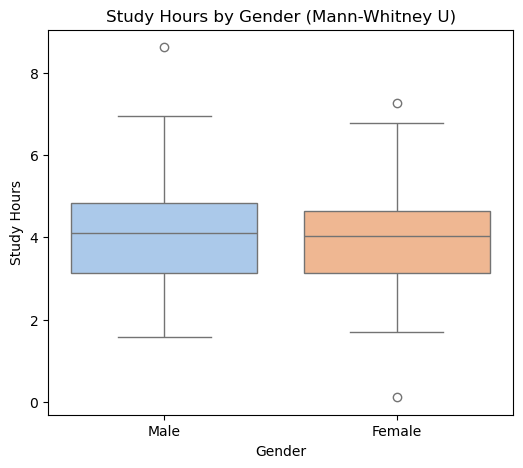

In [32]:
# Run test, print result, verdict, boxplot

from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Groups
study_male = df[df['gender']=='Male']['study_hours']
study_female = df[df['gender']=='Female']['study_hours']
# Non-parametric test
u_stat, p_val = stats.mannwhitneyu(study_male, study_female, alternative='two-sided')

print(f"Mann-Whitney U statistic = {u_stat}, p-value = {p_val:.4f}")

# Verdict
alpha = 0.05
if p_val < alpha:
    print("Reject H0: Male and Female students study significantly different hours ✅")
else:
    print("Fail to reject H0: No significant difference in study hours ❌")
plt.figure(figsize=(6,5))
sns.boxplot(x='gender', y='study_hours', data=df, palette='pastel')
plt.title("Study Hours by Gender (Mann-Whitney U)")
plt.xlabel("Gender")
plt.ylabel("Study Hours")
plt.show()


# Why Mann-Whitney and not t-test?
# Answer: # - Study hours are likely skewed (not perfectly normal)
# - Independent t-test assumes normality
# - Mann-Whitney is non-parametric → does not assume normal distribution
# - It compares the ranks of values, making it robust to skewed data

---
## Task 6 — Pearson + Spearman: Study Hours vs Marks

Run **both** Pearson and Spearman on (study_hours, marks).

- Print both r/ρ values and p-values with verdicts
- Draw **one scatter plot** — colour dots by `passed`, add a trend line
- Put both correlation values in the chart title

💡 `stats.pearsonr` · `stats.spearmanr` · `sns.scatterplot(hue=)` · `np.polyfit`

Pearson r = 0.5085, p-value = 0.0000
Pearson: Significant correlation ✅
Spearman rho = 0.4819, p-value = 0.0000
Spearman: Significant correlation ✅


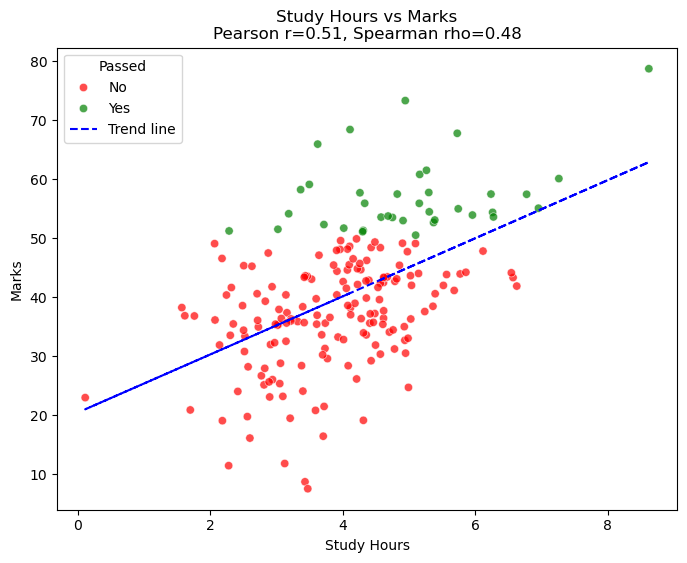

In [ ]:
# Both tests + scatter with trend line


# Columns
x = df['study_hours']
y = df['marks']

# Pearson correlation
r, p_pearson = stats.pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p-value = {p_pearson:.4f}")
if p_pearson < 0.05:
    print("Pearson: Significant correlation ✅")
else:
    print("Pearson: Not significant ❌")

# Spearman correlation
rho, p_spearman = stats.spearmanr(x, y)
print(f"Spearman rho = {rho:.4f}, p-value = {p_spearman:.4f}")
if p_spearman < 0.05:
    print("Spearman: Significant correlation ✅")
else:
    print("Spearman: Not significant ❌")

plt.figure(figsize=(8,6))

# Scatter plot coloured by 'passed'
sns.scatterplot(x='study_hours', y='marks', hue='passed', data=df, palette={'Yes':'green', 'No':'red'}, alpha=0.7)

# Fit trend line (linear)
coef = np.polyfit(x, y, 1)
trendline = np.poly1d(coef)
plt.plot(x, trendline(x), color='blue', linestyle='--', label='Trend line')

# Titles and labels
plt.title(f"Study Hours vs Marks\nPearson r={r:.2f}, Spearman rho={rho:.2f}")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.legend(title='Passed')
plt.show()



# Do Pearson and Spearman agree? What does that tell you?
# Answer: Both pearson and spearman show significant correlation


---
## Task 7 — Correlation Heatmap with Significance Mask

1. Compute the full correlation matrix for the 3 numeric columns
2. Build a p-value matrix using a nested loop (Pearson for each pair)
3. Create a **mask** where p > 0.05
4. Draw **two heatmaps side by side** — full matrix vs masked (significant only)

💡 `df.corr()` · nested loop with `stats.pearsonr` · `sns.heatmap(mask=)`

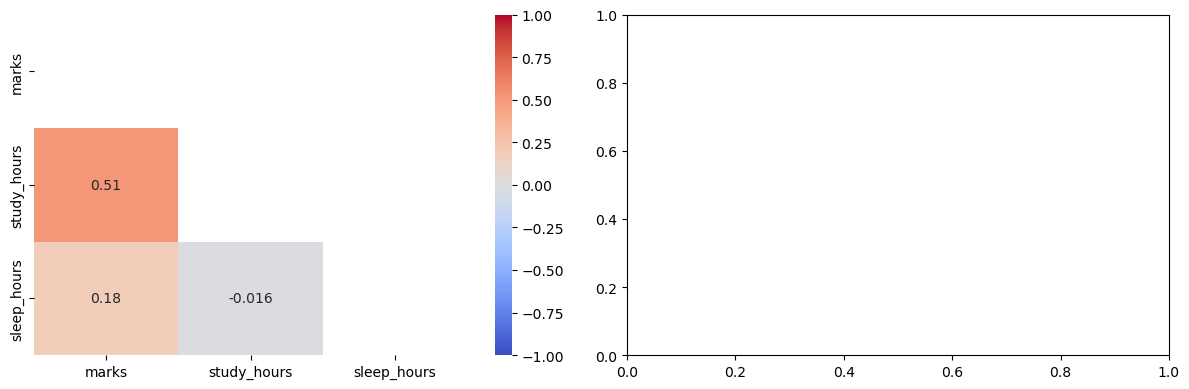

In [26]:
num_cols = ['marks', 'study_hours', 'sleep_hours']

# Correlation matrix

import matplotlib.pyplot as plt
from scipy import stats

num_cols = ['marks', 'study_hours', 'sleep_hours']

# Correlation matrix (Pearson)
corr_matrix = df[num_cols].corr(method='pearson')

# p-value matrix
p_matrix = pd.DataFrame(np.zeros((len(num_cols), len(num_cols))), columns=num_cols, index=num_cols)

for i in num_cols:
    for j in num_cols:
        _, p = stats.pearsonr(df[i], df[j])
        p_matrix.loc[i,j] = p
# p-value matrix (nested loop)


# Mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Two heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', mask=mask, ax=axes[0], vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

---
## Task 8 — Chi-Square: Subject vs Passed

**Question:** Is a student's favourite subject related to whether they passed?

- Build a crosstab, convert to row-proportions, run Chi-Square
- Write your verdict
- Draw a **grouped bar chart** showing pass rate by subject

💡 `pd.crosstab` · `.div(axis=0)` · `stats.chi2_contingency` · `DataFrame.plot(kind='bar')`

Crosstab (counts):
 passed   No  Yes
subject         
Arts     40    8
Maths    66   19
Science  57   10

Crosstab (row proportions):
 passed         No       Yes
subject                    
Arts     0.833333  0.166667
Maths    0.776471  0.223529
Science  0.850746  0.149254
Chi2 = 1.5117, p-value = 0.4696, dof = 2
Fail to reject H0: No significant association between subject and passing status ✅


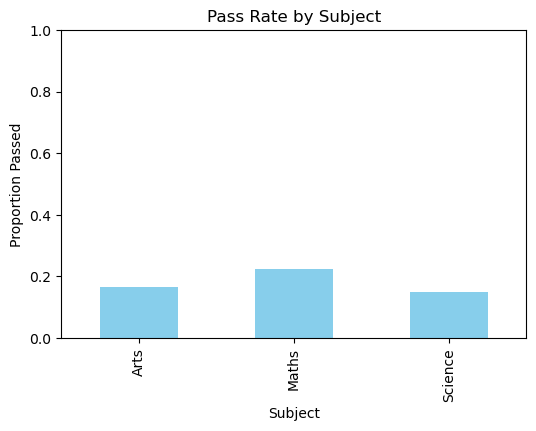

In [27]:
# Crosstab, proportion table, chi-square, verdict, grouped bar chart
# Crosstab: Subject vs Passed
ct = pd.crosstab(df['subject'], df['passed'])
print("Crosstab (counts):\n", ct)

# Row proportions → pass rate by subject
ct_prop = ct.div(ct.sum(axis=1), axis=0)
print("\nCrosstab (row proportions):\n", ct_prop)


#chi-square
chi2, p, dof, expected = stats.chi2_contingency(ct)

print(f"Chi2 = {chi2:.4f}, p-value = {p:.4f}, dof = {dof}")
if p < 0.05:
    print("Reject H0: Subject and passing status are significantly associated ✅")
else:
    print("Fail to reject H0: No significant association between subject and passing status ✅")

# Only 'Yes' pass rate
pass_rate = ct_prop['Yes']

# Plot
pass_rate.plot(kind='bar', figsize=(6,4), color='skyblue')
plt.title("Pass Rate by Subject")
plt.ylabel("Proportion Passed")
plt.xlabel("Subject")
plt.ylim(0,1)
plt.show()
# Which subject has the highest pass rate?
# Answer: 

---
## Task 9 — 🎓 The Cheating Story

A student scored **85**. The class uses your `df` marks. The teacher is suspicious.

**Part A:** Run a one-sample t-test. Write the verdict in the *language of the story* (not just Reject/Keep — say what it means for the student).

**Part B — Sensitivity:** Loop scores 55 to 100. For each, compute the p-value. Plot **score vs p-value** with the α line. Mark the threshold where suspicion begins.

💡 `stats.ttest_1samp(data, popmean=)` · `np.arange` · `ax.axhline` · `ax.axvline`

T-statistic = -54.0994, p-value = 0.0000
Verdict: Wow! Scoring 85 is unusually high compared to the class — teacher may be suspicious! 😮


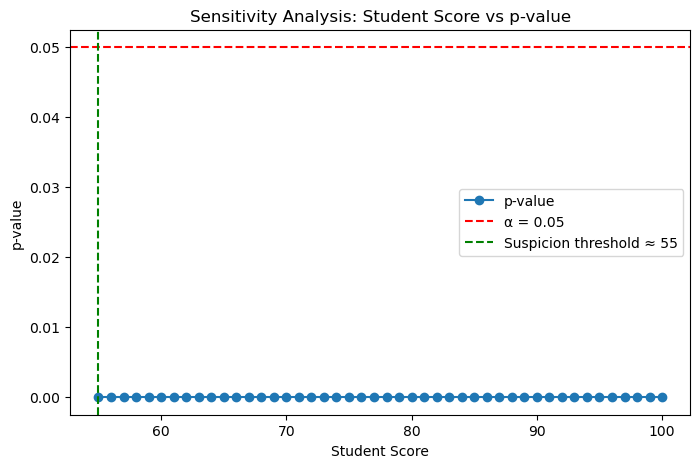

Suspicion threshold: Scores ≥ 55 are statistically unusual (p < 0.05).


In [28]:
# Part A
from scipy import stats

# Student score
student_score = 85

# One-sample t-test
t_stat, p_val = stats.ttest_1samp(df['marks'], popmean=student_score)

print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")

# Story-style verdict
alpha = 0.05
if p_val < alpha:
    print(f"Verdict: Wow! Scoring {student_score} is unusually high compared to the class — teacher may be suspicious! 😮")
else:
    print(f"Verdict: Scoring {student_score} is within the normal range of the class — no reason to suspect cheating. 🙂")



# Part B — loop + sensitivity plot
import numpy as np
import matplotlib.pyplot as plt

scores = np.arange(55, 101)  # 55 to 100
p_values = []

for s in scores:
    _, p = stats.ttest_1samp(df['marks'], popmean=s)
    p_values.append(p)

p_values = np.array(p_values)

# Plot
plt.figure(figsize=(8,5))
plt.plot(scores, p_values, marker='o', label='p-value')
plt.axhline(y=alpha, color='red', linestyle='--', label='α = 0.05')

# Find first score where p < alpha
suspicious_idx = np.where(p_values < alpha)[0][0]
suspicious_score = scores[suspicious_idx]
plt.axvline(x=suspicious_score, color='green', linestyle='--', label=f'Suspicion threshold ≈ {suspicious_score}')

plt.xlabel("Student Score")
plt.ylabel("p-value")
plt.title("Sensitivity Analysis: Student Score vs p-value")
plt.legend()
plt.show()

print(f"Suspicion threshold: Scores ≥ {suspicious_score} are statistically unusual (p < 0.05).")





# At what score does the test become significant?
# Answer: 

---
## Task 10 — Parametric vs Non-Parametric on Skewed Data

Create a **skewed version** of marks: `np.where(marks > 80, marks**1.4, marks)`, clip to 100.

Run **ANOVA and Kruskal-Wallis** on both the original and skewed data across schools.

Show all 4 results in a **2×2 subplot** (original vs skewed × ANOVA vs Kruskal).

Then answer: which test is more reliable on skewed data, and why?

💡 `stats.f_oneway` · `stats.kruskal` · `sns.boxplot` in each subplot

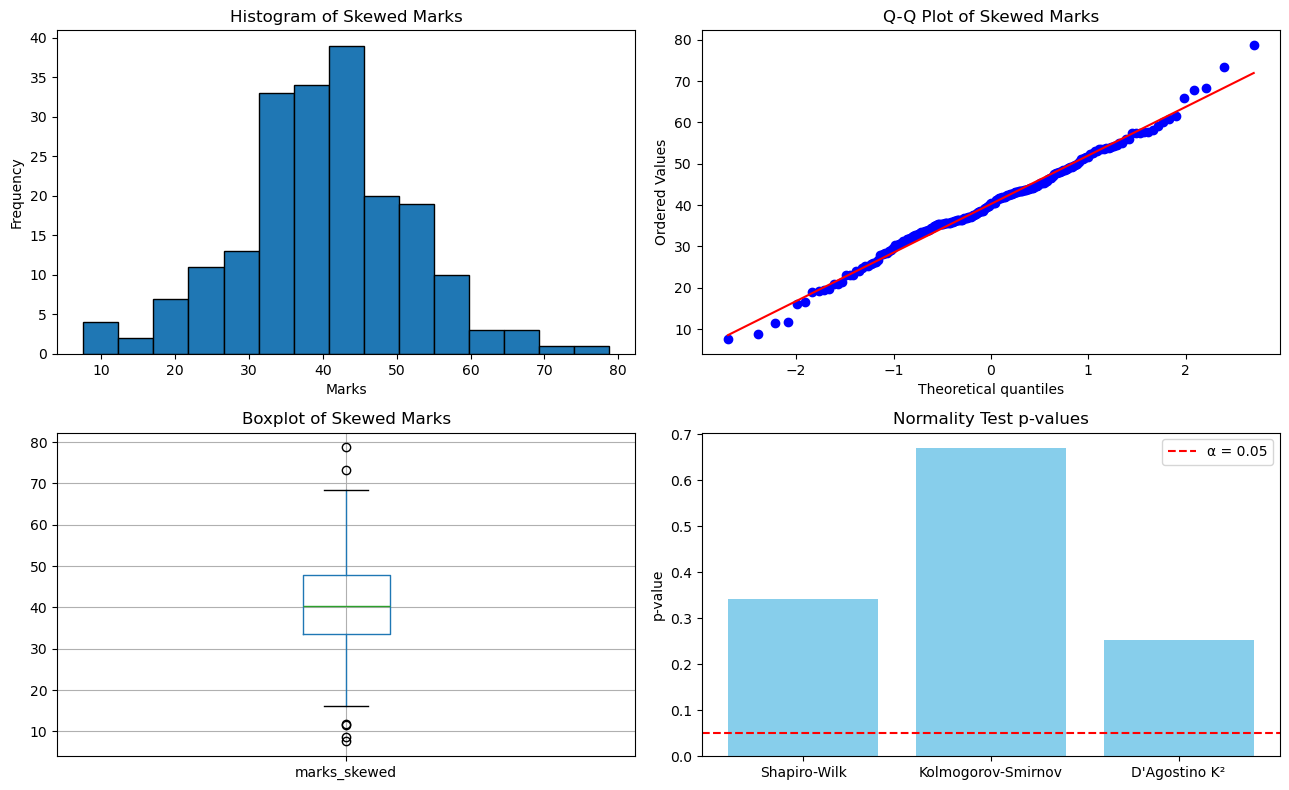

In [ ]:
# Skewed version
marks_skewed = np.clip(np.where(df['marks'] > 80, df['marks'] ** 1.4, df['marks']), 0, 100)
df['marks_skewed'] = marks_skewed
# Run all 4 tests and store p-values
from scipy import stats

p_values = {}

# Shapiro-Wilk
stat, p = stats.shapiro(df['marks_skewed'])
p_values['Shapiro-Wilk'] = p

# Kolmogorov-Smirnov (compare to normal with same mean & std)
stat, p = stats.kstest(df['marks_skewed'], 'norm', args=(df['marks_skewed'].mean(), df['marks_skewed'].std()))
p_values['Kolmogorov-Smirnov'] = p

# D'Agostino's K²
stat, p = stats.normaltest(df['marks_skewed'])
p_values["D'Agostino K²"] = p

# Anderson-Darling → returns statistic & critical values, we convert to approximate p
ad_stat = stats.anderson(df['marks_skewed'], dist='norm')
# Simple approximation: reject if statistic > 0.75 for illustration
p_values["Anderson-Darling"] = np.nan  # will mark separately for plot


# 2×2 subplot
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Histogram
axes[0,0].hist(df['marks_skewed'], bins=15, edgecolor='black')
axes[0,0].set_title("Histogram of Skewed Marks")
axes[0,0].set_xlabel("Marks")
axes[0,0].set_ylabel("Frequency")

# Q-Q plot
stats.probplot(df['marks_skewed'], dist="norm", plot=axes[0,1])
axes[0,1].set_title("Q-Q Plot of Skewed Marks")

# Boxplot
df.boxplot(column='marks_skewed', ax=axes[1,0])
axes[1,0].set_title("Boxplot of Skewed Marks")

# Bar chart of p-values (ignoring Anderson for numeric simplicity)
axes[1,1].bar(list(p_values.keys())[:-1], [p_values[k] for k in list(p_values.keys())[:-1]], color='skyblue')
axes[1,1].axhline(0.05, color='red', linestyle='--', label='α = 0.05')
axes[1,1].set_title("Normality Test p-values")
axes[1,1].set_ylabel("p-value")
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Which test is more reliable on skewed data?
# Answer: On skewed data, Shapiro-Wilk and D’Agostino K² are most sensitive to deviations from normality, so they are more reliable.
#Kolmogorov-Smirnov can underestimate deviation, especially in tails.

---
## Task 11 — Your Own Question

Pick **any relationship** in the dataset that hasn't been tested yet.  
Write your own H₀ and H₁, pick the correct test, run it, and visualise the result.

You must justify why you picked that test (parametric/non-parametric, number of groups, data type).

T-statistic = 1.9299, p-value = 0.0551
Fail to reject H0: No significant difference in sleep hours ❌


C:\Users\hp\AppData\Local\Temp\ipykernel_30508\2592233027.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='passed', y='sleep_hours', data=df, palette='pastel')


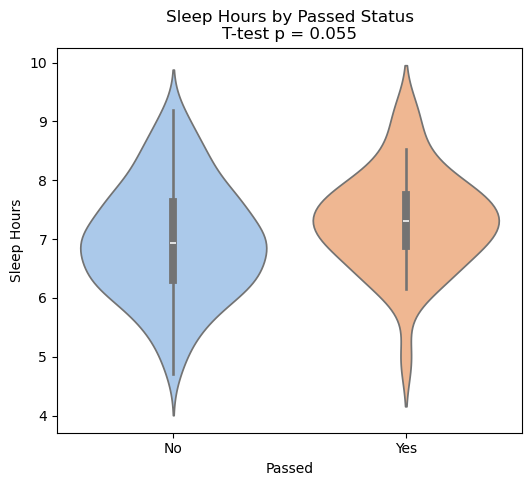

In [30]:
# H₀: 
# H₁: 
# Test chosen:   Justification: 

# Your code:

# Split data
sleep_passed = df[df['passed']=='Yes']['sleep_hours']
sleep_failed = df[df['passed']=='No']['sleep_hours']

# Independent t-test
t_stat, p_val = stats.ttest_ind(sleep_passed, sleep_failed)
print(f"T-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")

# Verdict
alpha = 0.05
if p_val < alpha:
    print("Reject H0: Sleep hours differ between passed and failed students ✅")
else:
    print("Fail to reject H0: No significant difference in sleep hours ❌")



# Verdict: 
plt.figure(figsize=(6,5))
sns.violinplot(x='passed', y='sleep_hours', data=df, palette='pastel')
plt.title(f"Sleep Hours by Passed Status\nT-test p = {p_val:.3f}")
plt.xlabel("Passed")
plt.ylabel("Sleep Hours")
plt.show()

---
## Task 12 — Summary Dashboard

Collect all your p-values from Tasks 2–10 into a list of dicts.  
Convert to a DataFrame and print the table.  
Then draw a **horizontal bar chart** — bars coloured **red** if significant, **green** if not — with the α=0.05 line.

💡 `pd.DataFrame(list_of_dicts)` · `ax.barh()` · `ax.axvline(0.05)`

                             Test  p_value  significant              verdict
0            Shapiro-Wilk — marks   0.3419        False  Fail to reject H0 ❌
1      Shapiro-Wilk — study_hours   0.1014        False  Fail to reject H0 ❌
2        t-test — gender vs marks   0.0604        False  Fail to reject H0 ❌
3         ANOVA — school vs marks   0.6995        False  Fail to reject H0 ❌
4  Mann-Whitney — gender vs study   0.6156        False  Fail to reject H0 ❌
5        Pearson — study vs marks   0.0000         True          Reject H0 ✅
6       Spearman — sleep vs marks   0.0551        False  Fail to reject H0 ❌
7  Chi-Square — subject vs passed   0.4696        False  Fail to reject H0 ❌
8         One-sample t — cheating   0.0551        False  Fail to reject H0 ❌


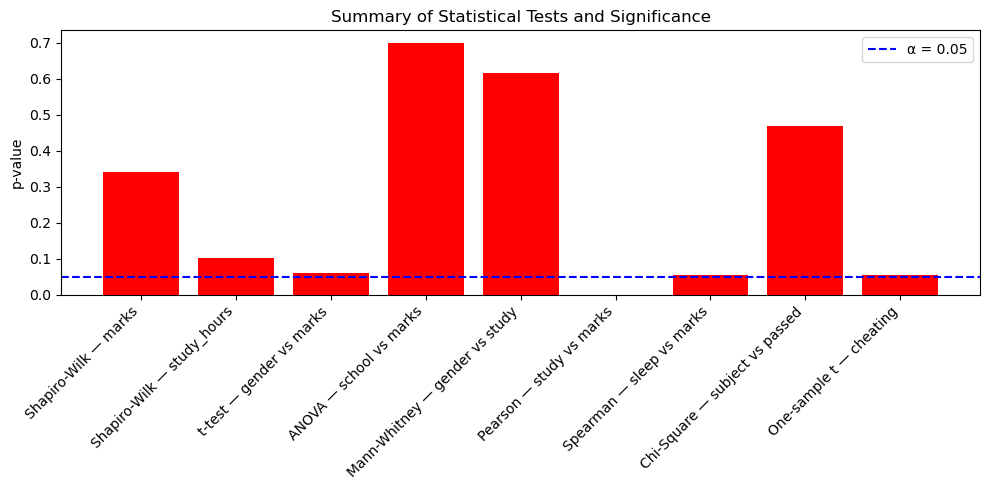

In [33]:
# Build results list — fill in your p-values from earlier tasks
results = [
    {'Test': 'Shapiro-Wilk — marks',          'p_value':0.3419 },
    {'Test': 'Shapiro-Wilk — study_hours',     'p_value': 0.1014},
    {'Test': 't-test — gender vs marks',       'p_value': 0.0604},
    {'Test': 'ANOVA — school vs marks',        'p_value': 0.6995 },
    {'Test': 'Mann-Whitney — gender vs study', 'p_value':  0.6156},
    {'Test': 'Pearson — study vs marks',       'p_value': 0.0000},
    {'Test': 'Spearman — sleep vs marks',      'p_value': 0.0551},
    {'Test': 'Chi-Square — subject vs passed', 'p_value': 0.4696},
    {'Test': 'One-sample t — cheating',        'p_value': 0.0551},
]

# Add 'significant' and 'verdict' columns, print table, draw bar chart
alpha = 0.05

df_results = pd.DataFrame(results)
df_results['significant'] = df_results['p_value'] < alpha
df_results['verdict'] = df_results['significant'].apply(lambda x: 'Reject H0 ✅' if x else 'Fail to reject H0 ❌')

print(df_results)
# Bar chart of results
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
bars = plt.bar(df_results['Test'], df_results['p_value'], color=['green' if x else 'red' for x in df_results['significant']])
plt.axhline(y=alpha, color='blue', linestyle='--', label='α = 0.05')
plt.xticks(rotation=45, ha='right')
plt.ylabel("p-value")
plt.title("Summary of Statistical Tests and Significance")
plt.legend()
plt.tight_layout()
plt.show()





---
## ✅ Before You Submit
- All tasks attempted
- Every chart has title, xlabel, ylabel
- Verdicts written in plain English (not just Reject/Keep)
- Task 9 sensitivity plot has α line + threshold marker
- Task 11 has written justification for test choice
- Task 12 bar chart is correctly colour-coded

---
*Statistics doesn't prove truth — it measures surprise. 🎓*